In [1]:
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
import pandas as po
import math
from sklearn import metrics
from sklearn.metrics import confusion_matrix

# Binary Classifier Evaluator

In [ ]:
!pip3 install pickle5
import pickle5 as pickle

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.1/132.1 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pickle5: filename=pickle5-0.0.11-cp310-cp310-linux_x86_64.whl size=256389 sha256=7cc713626573690d47e2ec61d9e675222d102c7f5c5622625d7b5bc05b403265
  Stored in directory: /root/.cache/pip/wheels/7d/14/ef/4aab19d27fa8e58772be5c71c16add0426acf9e1f64353235c
Successfully built pickle5


In [ ]:
#upload test labels and team's predictions
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

In [ ]:
#Should be probabilities
with open('team9_binary_prediction1.pkl', "rb") as fh:
  Group_Predictions = pickle.load(fh)
# Group_Predictions=po.DataFrame(po.read_pickle('team9_binary_pred.pkl')) #from student submission
Group_Predictions=Group_Predictions.apply(po.to_numeric)
Group_Predictions.values

array([[0.        , 0.96969876, 0.03030124],
       [0.        , 0.95254437, 0.04745563],
       [0.        , 0.88619548, 0.11380452],
       ...,
       [0.        , 0.91945628, 0.08054372],
       [0.        , 0.96439815, 0.03560185],
       [0.        , 0.96460223, 0.03539777]])

In [ ]:
print(len(Group_Predictions))

972


In [ ]:
all_test_labels=po.read_pickle("hypothyroid_binary_test_labels.pkl") #from GitHub
all_test_labels["class"]=po.get_dummies(all_test_labels["class"],drop_first=True)
all_test_labels

,class
0,0
1,0
2,0
3,0
4,0
...,...
967,0
968,0
969,0
970,0


In [ ]:
#for if the group omitted rows
required_testing_labels=po.DataFrame()
for i in Group_Predictions.index:
  required_testing_labels=required_testing_labels.append(all_test_labels.iloc[i])
len(required_testing_labels)

972

In [ ]:
# This is exactly the first metric you'll be evaluated on!
# Note: this will only work on the binary case -- let us know if you get to the multi-class case
def cm_metric(y_true,y_val_predict):
    # print(type(y_prob))
    # predict the class with the greatest probability
    # y_val_predict = [np.argmax(y) for y in y_prob]

    # calculate the confusion matrix
    cm = confusion_matrix(y_true, y_val_predict)
    print(cm)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    return sum(sum(np.multiply(cm_norm,np.array([[1, -4], [-4, 1]]))))

cm_metric(required_testing_labels,Group_Predictions.values[:,0])

[[892   9]
 [ 26  45]]


0.1190695784027137

[[892   9]
 [ 26  45]]


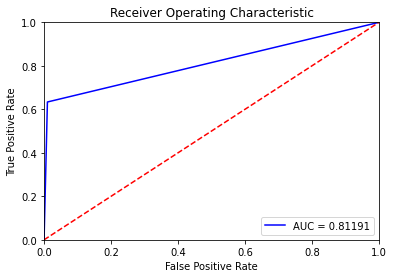

[[892   9]
 [ 26  45]]
0.1190695784027137
AUC:  0.8119069578402713
Score:  0.930976536242985


In [ ]:
###Point calculation


num_points=0.0
num_points+=cm_metric(required_testing_labels,Group_Predictions.values[:,0]) #max is 2

####
import matplotlib.mlab as mlab

fpr, tpr, threshold = metrics.roc_curve(required_testing_labels, Group_Predictions.values[:,0])
roc_auc = metrics.auc(fpr, tpr)
num_points+=roc_auc #max is 1

import matplotlib.pyplot as plt
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.5f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()
print(cm_metric(required_testing_labels,Group_Predictions.values[:,0]))
print("AUC: ",roc_auc)
print("Score: ",str(num_points)) #MAX score: (2+1)=3 points



# Multiclass Classifier Evaluator

In [ ]:
print(all_test_labels.shape)

(972, 1)


In [2]:
#upload test labels and team's predictions
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving team6_week1_multi.pkl to team6_week1_multi.pkl
User uploaded file "team6_week1_multi.pkl" with length 31995 bytes


In [4]:
#reading in the Group_Predictions as a data frame
Group_Predictions=po.DataFrame(po.read_pickle('team6_week1_multi.pkl')) #from student submission
Group_Predictions=Group_Predictions.apply(po.to_numeric)
Group_Predictions.head(10)

,prediction,0,1,2
0,0,0.999390,0.000536,0.000073
1,0,0.999701,0.000285,0.000013
2,0,0.970000,0.013333,0.016667
3,0,1.000000,0.000000,0.000000
4,0,1.000000,0.000000,0.000000
5,0,0.985691,0.014309,0.000000
6,0,0.997812,0.002180,0.000008
7,1,0.132242,0.814076,0.053682
8,0,0.999732,0.000263,0.000005
9,0,0.999168,0.000787,0.000044


In [5]:
all_test_labels=po.read_pickle("hypothyroid_multiclass_test_labels.pkl") #from github
print(type(all_test_labels)) #pandas DataFrame
print(all_test_labels.shape)

#Fixing the class variables
all_test_labels['class'] = all_test_labels['class'].replace('negative', 0)
all_test_labels['class'] = all_test_labels['class'].replace('compensated hypothyroid', 1)
all_test_labels['class'] = all_test_labels['class'].replace('primary hypothyroid', 2)

<class 'pandas.core.frame.DataFrame'>
(972, 1)


In [7]:
#Create a data frame of testing labels that correspond to the indices that the students used (the students may have omitted rows)
required_testing_labels=po.DataFrame()
for i in Group_Predictions.index:
  required_testing_labels=po.concat([required_testing_labels, all_test_labels.iloc[i]])

In [8]:
#check length of the testing labels (make sure it matches the team's length)
print(len(Group_Predictions.values))
print(len(required_testing_labels))

972
972


In [9]:
def cm_metric_complex(y_true,y_prob):
    # predict the class with the greatest probability
    y_val_predict = [np.argmax(y) for y in y_prob]

    # calculate the confusion matrix
    cm = confusion_matrix(y_true, y_val_predict)
    print(cm)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    return sum(sum(np.multiply(cm_norm,np.array([[1, -1,-2],
                                                 [-4, 2,-1],
                                                 [-8, -4,3]])))) #3 x 3 because 1 class value is so rare

#Argument 1 data type: pandas.DataFrame (of test labels) // Argument 2 data type: numpy.ndarray  (of the team's predictions)
cm_metric_complex(required_testing_labels, Group_Predictions.values)

[[  2 899   0]
 [ 40   0   0]
 [ 30   1   0]]


-12.866528230281766

In [10]:
#compiling the 1 multiclass class feature into 3 columns (one hot encoding))
#this puts the test labels into a format appropriate for computing the roc_curve function
one_hot_test_labels=po.get_dummies(all_test_labels["class"])
one_hot_test_labels

,0,1,2
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
967,1,0,0
968,1,0,0
969,1,0,0
970,1,0,0


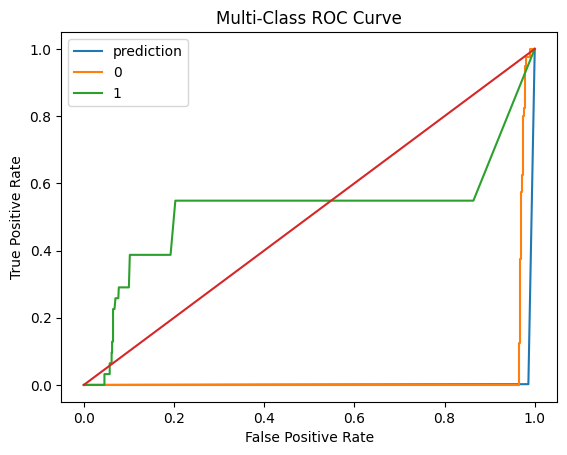

0.06119652746024489

In [11]:
#computing AUROC using a macro-type calculation
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(3):
  fpr[i], tpr[i], _ = metrics.roc_curve(one_hot_test_labels.iloc[:, i],Group_Predictions.iloc[:,i]) #compute each pos, fp rate for each class value
  roc_auc[i] = metrics.auc(fpr[i], tpr[i])
  plt.plot(fpr[i], tpr[i],label=Group_Predictions.columns[i])
plt.plot([0, 1], [0, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve')
plt.legend()
plt.show()

fpr["macro"], tpr["macro"], _ = metrics.roc_curve(one_hot_test_labels.values.ravel(), Group_Predictions.iloc[:,0:3].values.ravel())
roc_auc = metrics.auc(fpr["macro"], tpr["macro"])

roc_auc

In [ ]:
#feedback
print(cm_metric(required_testing_labels,Group_Predictions.values))
print("AUC: ",roc_auc)
print("Score: ",str(num_points))

NameError: ignored